<a href="https://colab.research.google.com/github/SSNEGI05/portfolio_analysis/blob/main/Statistical_DNA_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# PROJECT: THE STATISTICAL DNA OF THE INDIAN MARKET
# Goal: Analyze Higher-Order Moments (Skewness/Kurtosis) across Indices & Stocks
# Author: Shubham Negi
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Set visual style for the project
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

print("Project Environment Ready!")

Project Environment Ready!


In [3]:
# ------------------------------------------------------------------------------
# CELL 2: ROBUST DATA FETCHING
# ------------------------------------------------------------------------------

# Define Tickers (Using .NS for Indian Stocks)
tickers = ["^NSEI", "^NSEBANK", "RELIANCE.NS", "HDFCBANK.NS", "ADANIGREEN.NS", "tatapower.NS"]

# Parameters
START_DATE = "2015-01-01"
END_DATE = "2026-03-01"

print(f"Downloading data for: {tickers}...")

# Fetch data with auto_adjust=True to handle corporate actions automatically
# This ensures we get a clean 'Close' price that is already 'Adjusted'
data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)

# We extract only the 'Close' prices for all assets.
adj_close_data = data['Close']

# Calculate Daily Log Returns: ln(Price_t / Price_{t-1})
# We use .diff() on the logs for a cleaner implementation
returns = np.log(adj_close_data).diff().dropna()

print("\n--- Data successfully prepared ---")
print(f"Total trading days captured: {len(returns)}")
print(returns.head())

[**********************67%*******                ]  4 of 6 completed

[*********************100%***********************]  6 of 6 completed



--- Data successfully prepared ---
Total trading days captured: 1892
Ticker      ADANIGREEN.NS  HDFCBANK.NS  RELIANCE.NS  TATAPOWER.NS  ^NSEBANK  \
Date                                                                          
2018-06-19       0.034325     0.002152    -0.019388     -0.021564 -0.005450   
2018-06-20      -0.050325     0.016007     0.023025      0.006112  0.011054   
2018-06-21      -0.044525     0.000705     0.012383      0.009434 -0.002290   
2018-06-22      -0.006768     0.012437    -0.019028      0.021235  0.010135   
2018-06-25      -0.017124     0.005552    -0.007982      0.002623 -0.005888   

Ticker         ^NSEI  
Date                  
2018-06-19 -0.008312  
2018-06-20  0.005735  
2018-06-21 -0.002877  
2018-06-22  0.007490  
2018-06-25 -0.005504  


In [4]:
# ------------------------------------------------------------------------------
# CELL 3: THE ANALYSIS ENGINE - CALCULATING STATISTICAL MOMENTS
# ------------------------------------------------------------------------------

stats_list = []

for ticker in returns.columns:
    # Extract asset returns
    asset_returns = returns[ticker]

    # 1. Mean (Annualized)
    mean_ann = asset_returns.mean() * 252

    # 2. Volatility (Annualized Standard Deviation)
    vol_ann = asset_returns.std() * np.sqrt(252)

    # 3. Skewness
    asset_skew = skew(asset_returns)

    # 4. Excess Kurtosis (Fisher's definition: Normal = 0)
    asset_kurt = kurtosis(asset_returns)

    # Store results in a dictionary
    stats_list.append({
        "Ticker": ticker,
        "Annual Return": f"{mean_ann:.2%}",
        "Annual Volatility": f"{vol_ann:.2%}",
        "Skewness": round(asset_skew, 4),
        "Excess Kurtosis": round(asset_kurt, 4)
    })

# Convert to a clean DataFrame for display
stats_df = pd.DataFrame(stats_list).set_index("Ticker")

print("--- STATISTICAL DNA SUMMARY ---")
print(stats_df)

# Highlight 'Dangerous' Assets
print("\n--- Risk Flags ---")
for ticker, row in stats_df.iterrows():
    if float(row['Skewness']) < -0.5:
        print(f"⚠️ FLAG: {ticker} has High Negative Skew (Crash Risk).")
    if float(row['Excess Kurtosis']) > 3.0:
        print(f"⚠️ FLAG: {ticker} has High Excess Kurtosis (Fat Tail/Black Swan Risk).")

--- STATISTICAL DNA SUMMARY ---
              Annual Return Annual Volatility  Skewness  Excess Kurtosis
Ticker                                                                  
ADANIGREEN.NS        45.02%            54.73%    0.1357           5.9759
HDFCBANK.NS           7.77%            24.32%   -0.3524          10.2780
RELIANCE.NS          15.18%            28.19%    0.0622           9.2591
TATAPOWER.NS         22.97%            36.88%    0.1019           4.7135
^NSEBANK             10.48%            23.09%   -1.2819          20.2083
^NSEI                11.04%            17.38%   -1.4821          22.1726

--- Risk Flags ---
⚠️ FLAG: ADANIGREEN.NS has High Excess Kurtosis (Fat Tail/Black Swan Risk).
⚠️ FLAG: HDFCBANK.NS has High Excess Kurtosis (Fat Tail/Black Swan Risk).
⚠️ FLAG: RELIANCE.NS has High Excess Kurtosis (Fat Tail/Black Swan Risk).
⚠️ FLAG: TATAPOWER.NS has High Excess Kurtosis (Fat Tail/Black Swan Risk).
⚠️ FLAG: ^NSEBANK has High Negative Skew (Crash Risk).
⚠️ FLAG: ^

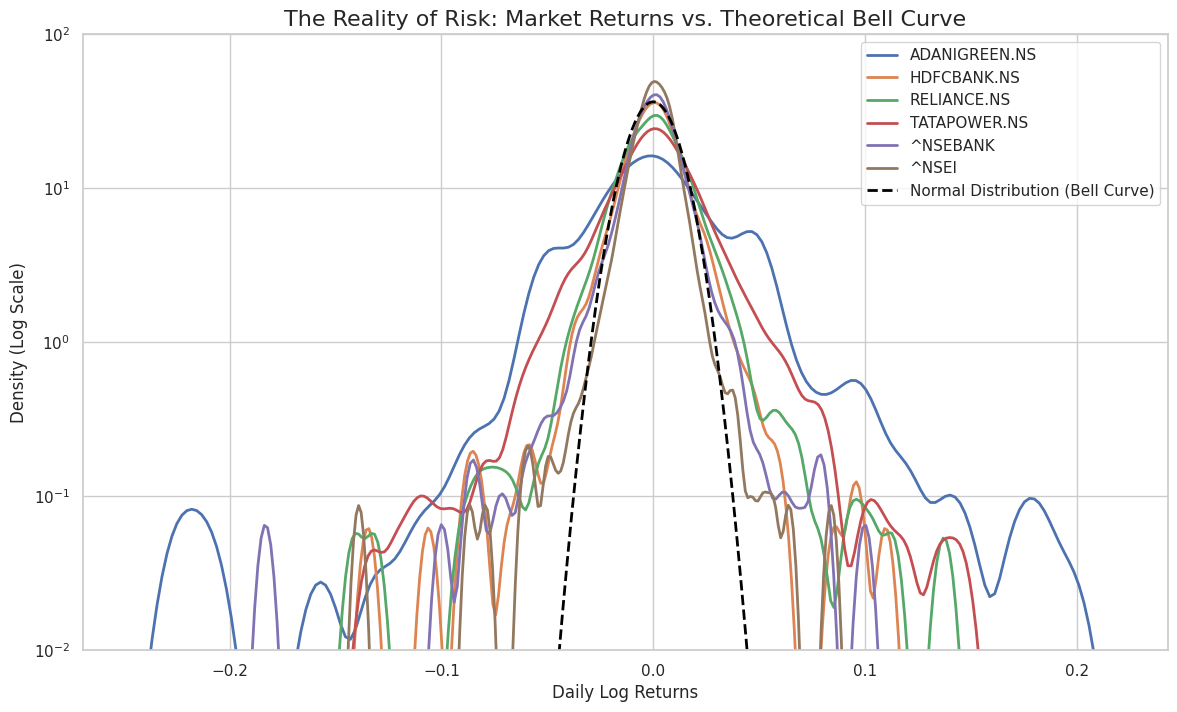

In [6]:
# ------------------------------------------------------------------------------
# CELL 4: VISUALIZING THE 'FAT TAILS' (FIXED & ROBUST)
# ------------------------------------------------------------------------------
import scipy.stats as stats

plt.figure(figsize=(14, 8))

# 1. Plot the real market data using KDE (Kernel Density Estimate)
for ticker in returns.columns:
    sns.kdeplot(returns[ticker], label=ticker, linewidth=2)

# 2. Create the "Ideal World" Normal Distribution for Nifty 50
# We use the mean and std of the actual Nifty returns
nifty_mu = 0 # In an ideal world, we center at 0
nifty_std = returns['^NSEI'].std()
x = np.linspace(returns.min().min(), returns.max().max(), 1000)
normal_pdf = stats.norm.pdf(x, nifty_mu, nifty_std)

# 3. Plot the Normal Curve
plt.plot(x, normal_pdf, color='black', linestyle='--', linewidth=2, label='Normal Distribution (Bell Curve)')

# 4. Styling the "Expert" way
plt.title("The Reality of Risk: Market Returns vs. Theoretical Bell Curve", fontsize=16)
plt.xlabel("Daily Log Returns")
plt.ylabel("Density (Log Scale)")
plt.yscale('log') # This highlights the FAT TAILS at the bottom
plt.ylim(1e-2, 1e2) # Limits to focus on the tails
plt.legend()
plt.show()

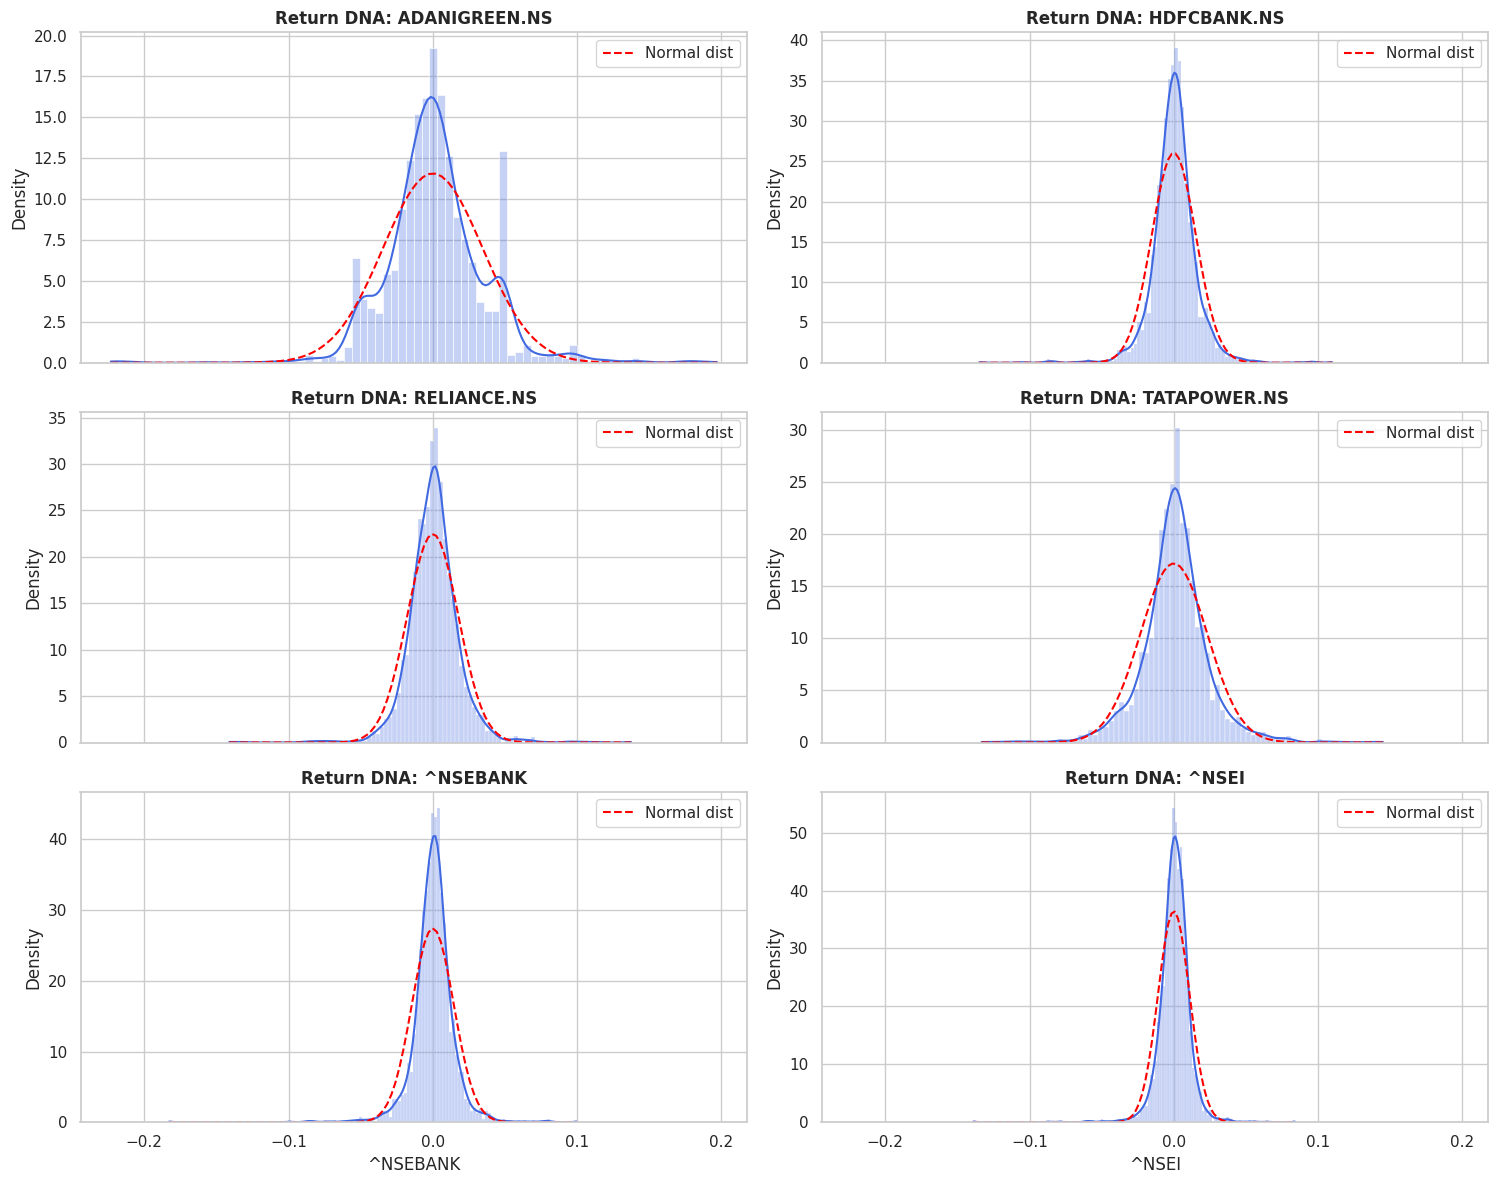

In [7]:
# ------------------------------------------------------------------------------
# CELL 5: INDIVIDUAL 'DNA' PLOTS (SUBPLOTS)
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

# 1. Setup the grid (Rows x Cols)
num_assets = len(returns.columns)
cols = 2
rows = (num_assets + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4), sharex=True)
axes = axes.flatten() # Flatten to 1D array for easy looping

# 2. Loop through each asset and give it its own plot
for i, ticker in enumerate(returns.columns):
    ax = axes[i]
    asset_data = returns[ticker].dropna()

    # Plot the Real Data (Histogram + KDE)
    sns.histplot(asset_data, kde=True, ax=ax, color='royalblue', stat="density", alpha=0.3)

    # Plot the Ideal "Normal" Curve for that specific asset's volatility
    mu, std = 0, asset_data.std()
    x = np.linspace(asset_data.min(), asset_data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, std), color='red', linestyle='--', label='Normal dist')

    ax.set_title(f"Return DNA: {ticker}", fontweight='bold')
    ax.set_ylabel("Density")
    ax.legend()

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()